In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import squarify

pd.set_option('display.float_format', lambda x: f'{x:,.2f}')
%matplotlib inline

CAMINHO = 'dados/'

dim_categoria   = pd.read_csv(CAMINHO + 'dim_categoria.csv')
dim_marca       = pd.read_csv(CAMINHO + 'dim_marca.csv')
dim_loja        = pd.read_csv(CAMINHO + 'dim_loja.csv')
dim_faixa_preco = pd.read_csv(CAMINHO + 'dim_faixa_preco.csv')
dim_produto     = pd.read_csv(CAMINHO + 'dim_produto.csv')
dim_data        = pd.read_csv(CAMINHO + 'dim_data.csv', parse_dates=['data_completa'])
fato_vendas     = pd.read_csv(CAMINHO + 'fato_vendas.csv')

print('fato_vendas:', fato_vendas.shape)
fato_vendas.head()


fato_vendas: (3100, 13)


,id_produto,id_categoria,id_marca,id_data,id_loja,id_faixa_preco,quantidade_vendida,preco_unitario,desconto_percentual,valor_bruto,valor_desconto,valor_liquido,status_estoque
0,1,1,1,20170803,1,3,28,59.90,0,"1,677.20",0.00,"1,677.20",Em estoque
1,1,1,1,20170831,2,3,9,59.90,15,539.10,80.86,458.24,Em estoque
2,1,1,1,20170926,1,3,23,59.90,5,"1,377.70",68.89,"1,308.82",Em estoque
3,1,1,1,20171021,1,3,7,59.90,0,419.30,0.00,419.30,Em estoque
4,1,1,1,20171118,1,3,22,59.90,0,"1,317.80",0.00,"1,317.80",Em estoque


In [2]:
# Junta a fato com as dimensões mais usadas, pra não repetir merge em toda célula
vendas = (fato_vendas
    .merge(dim_produto[['id_produto', 'nome_produto']], on='id_produto')
    .merge(dim_categoria[['id_categoria', 'nome_categoria']], on='id_categoria')
    .merge(dim_marca[['id_marca', 'nome_marca']], on='id_marca')
    .merge(dim_loja[['id_loja', 'nome_loja', 'tipo_canal']], on='id_loja')
    .merge(dim_data[['id_data', 'data_completa', 'ano', 'mes']], on='id_data')
)
vendas.head()


,id_produto,id_categoria,id_marca,id_data,id_loja,id_faixa_preco,quantidade_vendida,preco_unitario,desconto_percentual,valor_bruto,...,valor_liquido,status_estoque,nome_produto,nome_categoria,nome_marca,nome_loja,tipo_canal,data_completa,ano,mes
0,1,1,1,20170803,1,3,28,59.90,0,"1,677.20",...,"1,677.20",Em estoque,SHOW BRONZE SKIN ACTIVE BRONZE 100g,TRATAMENTO,Show Bronze,E-commerce Próprio,Direto,2017-08-03,2017,8
1,1,1,1,20170831,2,3,9,59.90,15,539.10,...,458.24,Em estoque,SHOW BRONZE SKIN ACTIVE BRONZE 100g,TRATAMENTO,Show Bronze,Mercado Livre,Marketplace,2017-08-31,2017,8
2,1,1,1,20170926,1,3,23,59.90,5,"1,377.70",...,"1,308.82",Em estoque,SHOW BRONZE SKIN ACTIVE BRONZE 100g,TRATAMENTO,Show Bronze,E-commerce Próprio,Direto,2017-09-26,2017,9
3,1,1,1,20171021,1,3,7,59.90,0,419.30,...,419.30,Em estoque,SHOW BRONZE SKIN ACTIVE BRONZE 100g,TRATAMENTO,Show Bronze,E-commerce Próprio,Direto,2017-10-21,2017,10
4,1,1,1,20171118,1,3,22,59.90,0,"1,317.80",...,"1,317.80",Em estoque,SHOW BRONZE SKIN ACTIVE BRONZE 100g,TRATAMENTO,Show Bronze,E-commerce Próprio,Direto,2017-11-18,2017,11


---
## 1. Visão Geral

### 1.1 KPIs principais

In [3]:
faturamento_liquido = vendas['valor_liquido'].sum()
qtde_vendida = vendas['quantidade_vendida'].sum()
ticket_medio = faturamento_liquido / len(vendas)
pct_desconto_medio = vendas['valor_desconto'].sum() / vendas['valor_bruto'].sum() * 100

print(f'Faturamento Líquido:  R$ {faturamento_liquido:,.2f}')
print(f'Quantidade Vendida:   {qtde_vendida:,.0f}')
print(f'Ticket Médio:         R$ {ticket_medio:,.2f}')
print(f'% Desconto Médio:     {pct_desconto_medio:.2f}%')


Faturamento Líquido:  R$ 4,082,325.28
Quantidade Vendida:   139,368
Ticket Médio:         R$ 1,316.88
% Desconto Médio:     7.40%


### 1.2 Faturamento Líquido por Mês, com comparação ano anterior (LY / YoY)

In [4]:
mensal = vendas.groupby(['ano', 'mes'])['valor_liquido'].sum().reset_index()
mensal['faturamento_ly'] = mensal.groupby('mes')['valor_liquido'].shift(1)
mensal['pct_yoy'] = (mensal['valor_liquido'] - mensal['faturamento_ly']) / mensal['faturamento_ly'] * 100
mensal['ano_mes'] = mensal['ano'].astype(str) + '-' + mensal['mes'].astype(str).str.zfill(2)

pct_yoy_geral = (faturamento_liquido - mensal.groupby('ano')['valor_liquido'].sum().pct_change().iloc[-1]) if False else None
mensal.tail(8)


,ano,mes,valor_liquido,faturamento_ly,pct_yoy,ano_mes
112,2026,1,"40,781.42","41,017.16",-0.57,2026-01
113,2026,2,"35,488.62","34,363.55",3.27,2026-02
114,2026,3,"32,427.38","29,577.88",9.63,2026-03
115,2026,4,"35,589.48","32,007.43",11.19,2026-04
116,2026,5,"33,427.49","37,816.72",-11.61,2026-05
117,2026,6,"31,635.03","32,588.57",-2.93,2026-06
118,2026,7,"34,110.33","37,513.38",-9.07,2026-07
119,2026,8,"24,779.94","30,742.69",-19.40,2026-08


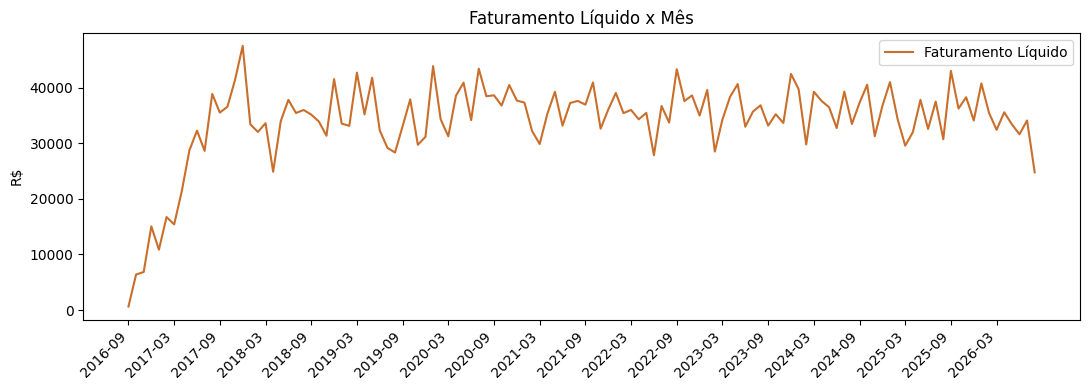

In [5]:
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(mensal['ano_mes'], mensal['valor_liquido'], label='Faturamento Líquido', color='#C96E2B')
ax.set_xticks(mensal['ano_mes'][::6])
ax.set_xticklabels(mensal['ano_mes'][::6], rotation=45, ha='right')
ax.set_title('Faturamento Líquido x Mês')
ax.set_ylabel('R$')
ax.legend()
plt.tight_layout()
plt.show()


### 1.3 Eficácia do desconto — a política de desconto aumenta o volume médio por venda?

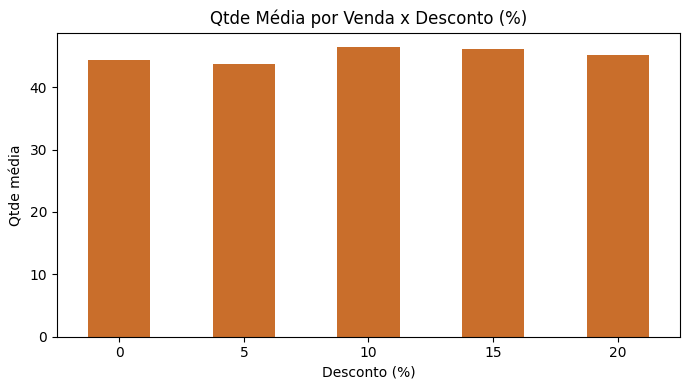

,qtde_vendas,qtde_media_por_venda
desconto_percentual,,
0,1319,44.40
5,432,43.80
10,440,46.40
15,474,46.10
20,435,45.10


In [6]:
eficacia_desconto = vendas.groupby('desconto_percentual').agg(
    qtde_vendas=('quantidade_vendida', 'count'),
    qtde_media_por_venda=('quantidade_vendida', 'mean')
).round(1)

eficacia_desconto['qtde_media_por_venda'].plot(
    kind='bar', title='Qtde Média por Venda x Desconto (%)', color='#C96E2B', figsize=(7, 4)
)
plt.ylabel('Qtde média')
plt.xlabel('Desconto (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

eficacia_desconto


### 1.4 Top 5 Produtos por Faturamento Líquido

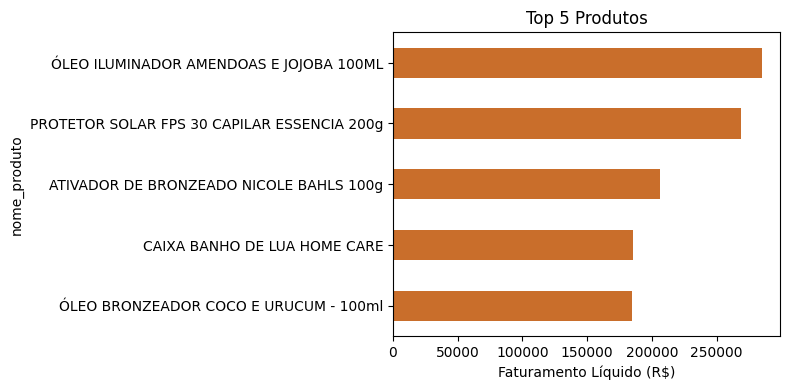

In [7]:
top5_produtos = vendas.groupby('nome_produto')['valor_liquido'].sum().nlargest(5).sort_values()

top5_produtos.plot(kind='barh', title='Top 5 Produtos', color='#C96E2B', figsize=(8, 4))
plt.xlabel('Faturamento Líquido (R$)')
plt.tight_layout()
plt.show()


---
## 2. Canais e Descontos


### 2.1 Faturamento por Loja

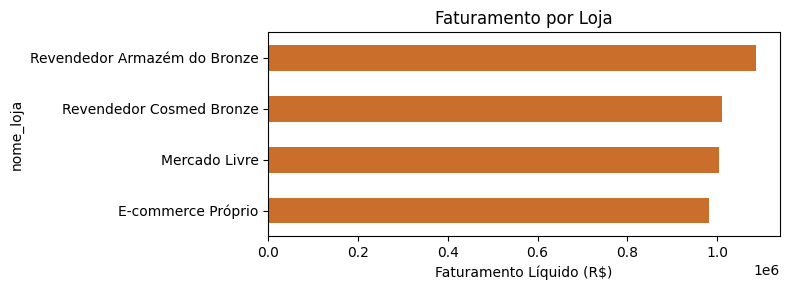

In [8]:
faturamento_loja = vendas.groupby('nome_loja')['valor_liquido'].sum().sort_values()

faturamento_loja.plot(kind='barh', title='Faturamento por Loja', color='#C96E2B', figsize=(8, 3))
plt.xlabel('Faturamento Líquido (R$)')
plt.tight_layout()
plt.show()


### 2.2 Faturamento por Tipo de Canal (Direto x Marketplace x B2B)

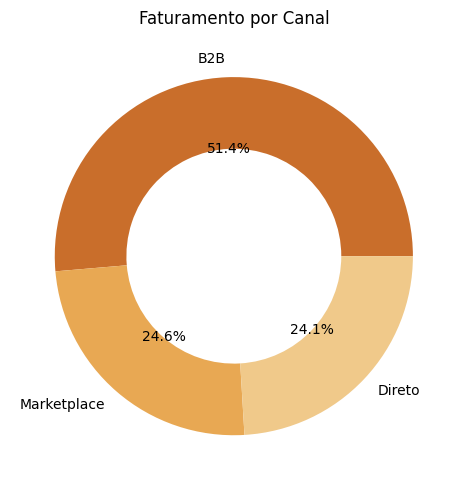

,faturamento,pct
tipo_canal,,
B2B,"2,096,340.81",51.35
Marketplace,"1,004,010.42",24.59
Direto,"981,974.05",24.05


In [9]:
faturamento_canal = vendas.groupby('tipo_canal')['valor_liquido'].sum().sort_values(ascending=False)
pct_canal = (faturamento_canal / faturamento_canal.sum() * 100).round(2)

fig, ax = plt.subplots(figsize=(5, 5))
cores = ['#C96E2B', '#E8A853', '#F0C98A']
ax.pie(faturamento_canal, labels=faturamento_canal.index, autopct='%1.1f%%', colors=cores,
       wedgeprops=dict(width=0.4))
ax.set_title('Faturamento por Canal')
plt.tight_layout()
plt.show()

pd.DataFrame({'faturamento': faturamento_canal, 'pct': pct_canal})


### 2.3 % Desconto Médio por Canal

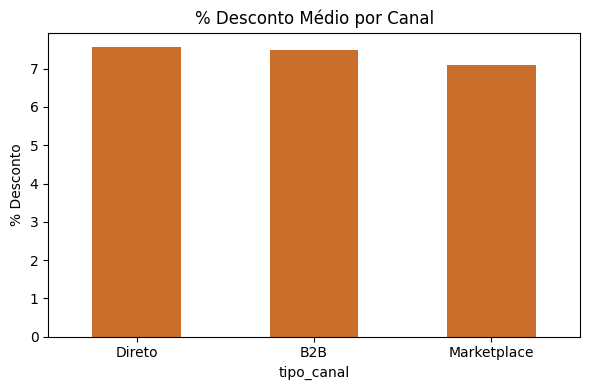

In [10]:
desconto_canal = vendas.groupby('tipo_canal').apply(
    lambda g: g['valor_desconto'].sum() / g['valor_bruto'].sum() * 100, include_groups=False
).round(2).sort_values(ascending=False)

desconto_canal.plot(kind='bar', title='% Desconto Médio por Canal', color='#C96E2B', figsize=(6, 4))
plt.ylabel('% Desconto')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


### 2.4 Qtde de Lojas Ativas

In [11]:
qtde_lojas_ativas = vendas['nome_loja'].nunique()
print(f'Lojas ativas: {qtde_lojas_ativas}')


Lojas ativas: 4


---
## 3. Produto e Categoria


### 3.1 Faturamento por Categoria (Treemap)

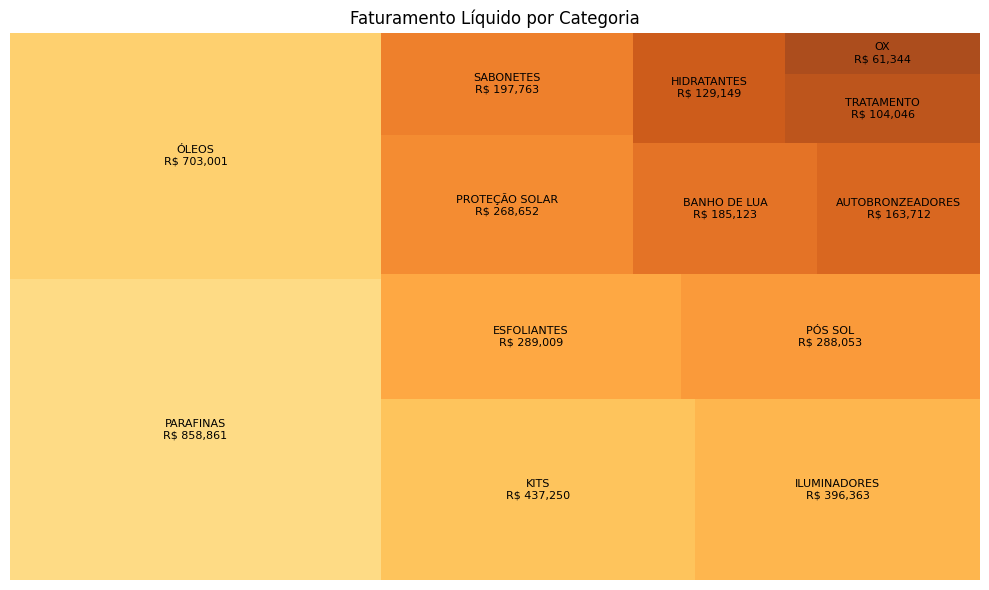

In [12]:
faturamento_categoria = vendas.groupby('nome_categoria')['valor_liquido'].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
cores_treemap = plt.cm.YlOrBr(np.linspace(0.3, 0.85, len(faturamento_categoria)))
labels = [f'{cat}\nR$ {val:,.0f}' for cat, val in faturamento_categoria.items()]
squarify.plot(sizes=faturamento_categoria.values, label=labels, color=cores_treemap,
              alpha=0.9, text_kwargs={'fontsize': 8}, ax=ax)
ax.set_title('Faturamento Líquido por Categoria')
ax.axis('off')
plt.tight_layout()
plt.show()


### 3.2 Matriz de Produtos — Ranking geral e % sobre o subtotal da categoria
Equivalente às medidas DAX `Ranking de Produtos` e `% sobre o Subtotal da Categoria` (com `ISINSCOPE`), e à query SQL com `RANK() OVER` e `SUM() OVER (PARTITION BY...)`.

In [13]:
produto_totais = vendas.groupby(['nome_categoria', 'nome_produto'])['valor_liquido'].sum().reset_index()

produto_totais['ranking_geral'] = produto_totais['valor_liquido'].rank(ascending=False, method='min').astype(int)
produto_totais['pct_sobre_subtotal_categoria'] = (
    produto_totais.groupby('nome_categoria')['valor_liquido']
    .transform(lambda x: x / x.sum() * 100)
).round(2)

matriz_produtos = produto_totais.sort_values(['nome_categoria', 'valor_liquido'], ascending=[True, False])
matriz_produtos.head(10)


,nome_categoria,nome_produto,valor_liquido,ranking_geral,pct_sobre_subtotal_categoria
0,AUTOBRONZEADORES,MOUSSE AUTOBRONZEADOR - 140ml,"163,712.43",12,100.00
1,BANHO DE LUA,CAIXA BANHO DE LUA HOME CARE,"185,122.82",4,100.00
3,ESFOLIANTES,ESFOLIANTE PRÉ-BRONZE - 250g,"164,001.48",11,56.75
2,ESFOLIANTES,ESFOLIANTE EM PÓ CORPORAL GOLDEN CLARITY 100g,"125,007.78",19,43.25
4,HIDRATANTES,HIDRATANTE CORPORAL GOLDEN CLARITY 100g,"129,148.92",18,100.00
6,ILUMINADORES,ÓLEO ILUMINADOR AMENDOAS E JOJOBA 100ML,"284,771.79",1,71.85
5,ILUMINADORES,NICOLE BAHLS ILUMINADOR CORPORAL VERÃO INTENSO...,"111,591.00",21,28.15
9,KITS,KIT TRIO PERFEITO (ÓLEO URUCUM E MELANCIA E IL...,"175,769.12",9,40.20
7,KITS,KIT BRONZE ROTINA (MOUSSE+ESFOLIANTE+SABONETE),"138,433.35",17,31.66
8,KITS,KIT GOLDEN CLARITY HOME,"123,047.24",20,28.14


In [14]:
# Validação: a soma dos % dentro de cada categoria deve dar 100%
validacao = matriz_produtos.groupby('nome_categoria')['pct_sobre_subtotal_categoria'].sum().round(1)
print('Todas as categorias somam 100%?', (validacao == 100.0).all())
validacao


Todas as categorias somam 100%? True


nome_categoria
AUTOBRONZEADORES   100.00
BANHO DE LUA       100.00
ESFOLIANTES        100.00
HIDRATANTES        100.00
ILUMINADORES       100.00
KITS               100.00
OX                 100.00
PARAFINAS          100.00
PROTEÇÃO SOLAR     100.00
PÓS SOL            100.00
SABONETES          100.00
TRATAMENTO         100.00
ÓLEOS              100.00
Name: pct_sobre_subtotal_categoria, dtype: float64

---
## 4. Conclusões

- **Faturamento Líquido total:** valor calculado na Seção 1.1 — deve bater com o card do Power BI (R$ 4.082.325,28, se os dados forem os mesmos da limpeza original).
- **Desconto não aumenta volume médio de venda** (Seção 1.3) — a quantidade média por venda fica estável entre ~44 e ~46 unidades, independente do percentual de desconto aplicado.
- **Canal B2B concentra a maior fatia do faturamento** (Seção 2.2), mesmo sendo só 2 das 4 lojas ativas.
- Os números deste notebook foram cruzados com o relatório Power BI e com as queries SQL do mesmo projeto — as três ferramentas concordam, o que dá confiança na análise.
